In [1]:
import pandas as pd
import numpy as np
close=pd.read_csv('D:/python-practise/data-analyse/crypto/close_clean.csv',index_col=0,parse_dates=True)
signal=np.sign(close.pct_change(90)).shift(1)
print(signal.iloc[100:105,:5])
print(signal.stack().value_counts())

                           BTC/USDT  ETH/USDT  BNB/USDT  XRP/USDT  SOL/USDT
ts                                                                         
2020-04-10 00:00:00+00:00      -1.0       1.0      -1.0      -1.0       NaN
2020-04-11 00:00:00+00:00      -1.0       1.0      -1.0      -1.0       NaN
2020-04-12 00:00:00+00:00      -1.0       1.0      -1.0      -1.0       NaN
2020-04-13 00:00:00+00:00      -1.0       1.0      -1.0      -1.0       NaN
2020-04-14 00:00:00+00:00      -1.0      -1.0      -1.0      -1.0       NaN
-1.0    28691
 1.0    25094
 0.0      852
Name: count, dtype: int64


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\463445652.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signal=np.sign(close.pct_change(90)).shift(1)


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\1835370328.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  strategy_ret=signal*close.pct_change()


Final nav： 2.5326958919561635


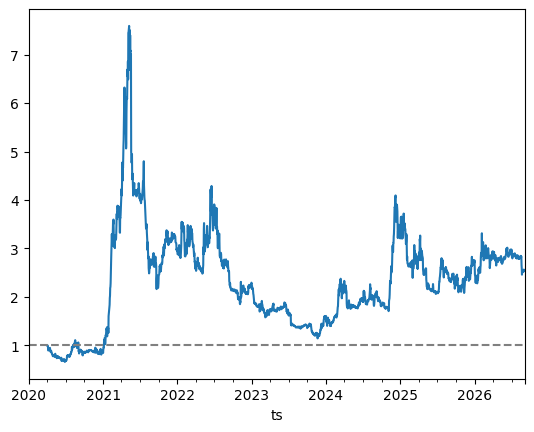

<Figure size 640x480 with 0 Axes>

In [2]:
strategy_ret=signal*close.pct_change()
port_ret=strategy_ret.mean(axis=1)
nav=(1+port_ret).cumprod()
import matplotlib.pyplot as plt
print('Final nav：',nav.iloc[-1])
nav.plot()
plt.axhline(1, ls='--', color='gray')
plt.show()
plt.savefig('time series momentum.png', dpi=150, bbox_inches='tight')

In [3]:
win_rate=(strategy_ret>0).stack().mean()
print("win rate：",win_rate)
turnover=signal.diff().abs().mean(axis=1)
cost=turnover*0.001
net_ret=strategy_ret.mean(axis=1)-cost
nav_ret=(1+net_ret).cumprod()
print("Final nav with cost：",nav_ret.iloc[-1])
split = int(len(net_ret) * 0.7)
nav_in= (1+net_ret.iloc[:split]).cumprod()   # 前70%
nav_out = (1+net_ret.iloc[split:]).cumprod()  # 后30%
print("In sample:", nav_in.iloc[-1], "out sample:", nav_out.iloc[-1])

win rate： 0.3413786915504512
Final nav with cost： 2.056472796080112
In sample: 1.7828325938961511 out sample: 1.1534862011839013


In [4]:
print("Daily Turnover describe:\n", turnover.describe())
print("average cost per day:", cost.mean())
print("gross return per day:", strategy_ret.mean(axis=1).mean())

Daily Turnover describe:
 count    2346.000000
mean        0.089079
std         0.126071
min         0.000000
25%         0.000000
50%         0.062500
75%         0.142857
max         1.000000
dtype: float64
average cost per day: 8.907883704231661e-05
gross return per day: 0.0008580021029176872


In [5]:
returns=close.pct_change()
mom_factor=pd.read_csv("mom_factor.csv",index_col=0,parse_dates=True)
print("returns max:", returns.max().max())
print("returns min:", returns.min().min())
print("returns describe:\n", returns.stack().describe())

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\1750067137.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns=close.pct_change()


returns max: 3.9241136474016507
returns min: -0.47782231653960017
returns describe:
 count    57517.000000
mean         0.001823
std          0.056847
min         -0.477822
25%         -0.023408
50%          0.000000
75%          0.022569
max          3.924114
dtype: float64


In [6]:
# Cross-sectional binarization to signals
cross_signal = np.sign(mom_factor)
cross_ret_fair = (cross_signal * returns).mean(axis=1)
nav1_fair = (1 + cross_ret_fair).cumprod()
print("cross section final nav:", nav1_fair.iloc[-1])

cross section final nav: 1.3227992051883661


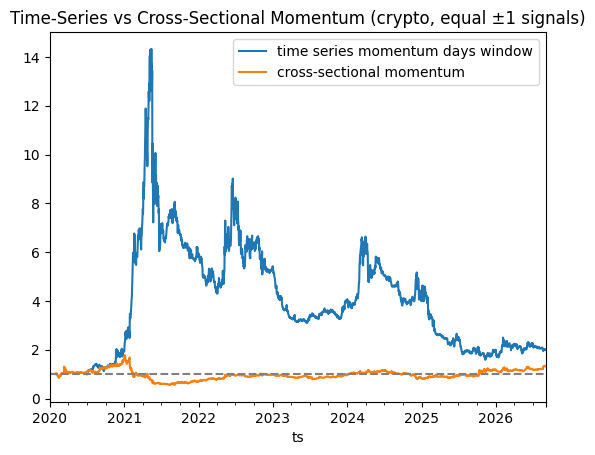

<Figure size 640x480 with 0 Axes>

In [9]:
nav.plot(label="time series momentum days window")
nav1_fair.plot(label="cross-sectional momentum")
plt.axhline(1, ls='--', color='gray')
plt.legend()
plt.title("Time-Series vs Cross-Sectional Momentum (crypto, equal ±1 signals)")
plt.show()
plt.savefig('momentum comparison(90 days).png', dpi=150, bbox_inches='tight')

In [8]:
results = {}
for i in [30, 60, 90, 180]:
    momentum = close.pct_change(i)
    signal = np.sign(momentum).shift(1)
    port_ret = (signal * close.pct_change()).mean(axis=1)   # 补上 .mean(axis=1)
    nav = (1 + port_ret).cumprod()
    results[i]=nav
    print(f"{i}days window final nav: {nav.iloc[-1]:.3f}")

30days window final nav: 14.964
60days window final nav: 4.037
90days window final nav: 2.533
180days window final nav: 1.988


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\377675198.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  momentum = close.pct_change(i)
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\377675198.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  port_ret = (signal * close.pct_change()).mean(axis=1)   # 补上 .mean(axis=1)
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_10576\377675198.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_chang

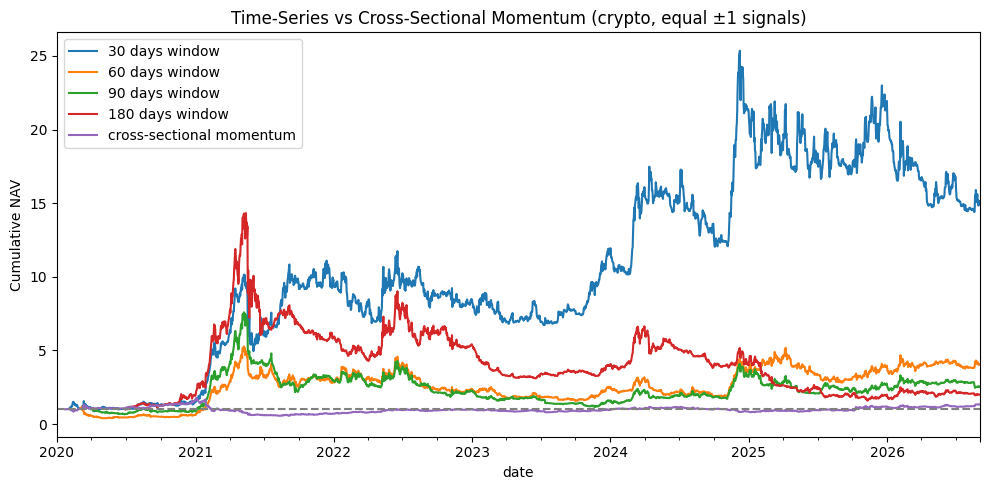

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(10,5))
for i,nav in results.items():
    nav.plot(label=f"{i} days window")
nav1_fair.plot(label="cross-sectional momentum")
plt.axhline(1, ls='--', color='gray')     # 本金线
plt.legend()                               # 显示图例
plt.title('Time-Series vs Cross-Sectional Momentum (crypto, equal ±1 signals)')
plt.xlabel('date')
plt.ylabel('Cumulative NAV')
plt.tight_layout()
plt.show()
plt.savefig('momentum comparison(different days window).png', dpi=150, bbox_inches='tight')